In [697]:
library(car)
library(glmnet)
library(GGally)
library(ComplexHeatmap)
library(ggplotify)

In [698]:
lipid_meta = read.csv('../data/var_importance.b1.csv')

In [728]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

became_data = scaled_df[rownames(subset(meta,cohort=='BECAME')),]
became_meta = meta[rownames(became_data),]
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'cluster']=='B1'))


Total Observations: 175 
Events: 25 
Predictors: 161 
EPV: 0.1552795 


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Minimum VIF: 131.9557 


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


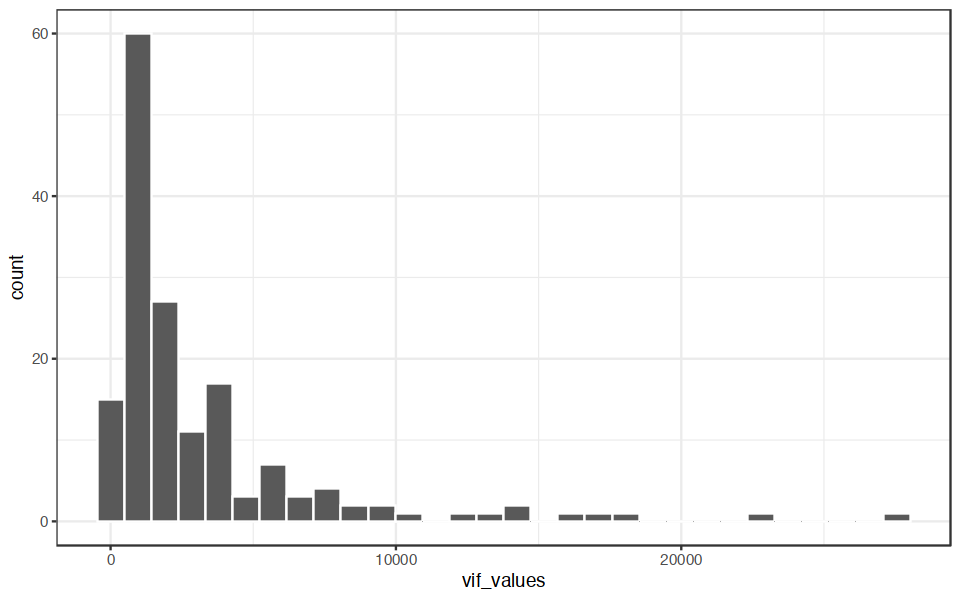

In [729]:
# Check the number of observations and events
total_obs <- nrow(became_data)
events <- sum(became_data$response_var == 1)

# Check EPV
predictor_count <- ncol(became_data) - 1  # Excluding the response variable
epv <- events / predictor_count

# Display results
cat("Total Observations:", total_obs, "\n")
cat("Events:", events, "\n")
cat("Predictors:", predictor_count, "\n")
cat("EPV:", epv, "\n")

# Check for multicollinearity using VIF
vif_values <- vif(glm(response_var ~ ., data = became_data, family = "binomial"))


# Display VIF values as histogram
options(repr.plot.width = 8, repr.plot.height = 5)

vif_values = data.frame(vif_values)
vif_values$lipid = rownames(vif_values)
cat("Minimum VIF:", min(vif_values$vif_values), "\n")
ggplot(vif_values,aes(vif_values))+
    geom_histogram(col='white')+
    theme_bw()

In [730]:
## Find optimal lambda parameter using CV

index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
became_data_train = became_data

x = became_data[,grepl('^X',colnames(became_data))]
y = became_data$response_var
cv_model <- cv.glmnet(as.matrix(x), y, alpha = 1,family='binomial')

In [731]:
lambda_min <- cv_model$lambda.min
lambda_1se <- cv_model$lambda.1se

In [732]:
cat('Min Lambda: ',best_lambda,'\n')
cat('1-SE Lambda: ',lambda_1se,'\n')

Min Lambda:  0.01106215 
1-SE Lambda:  0.03644031 


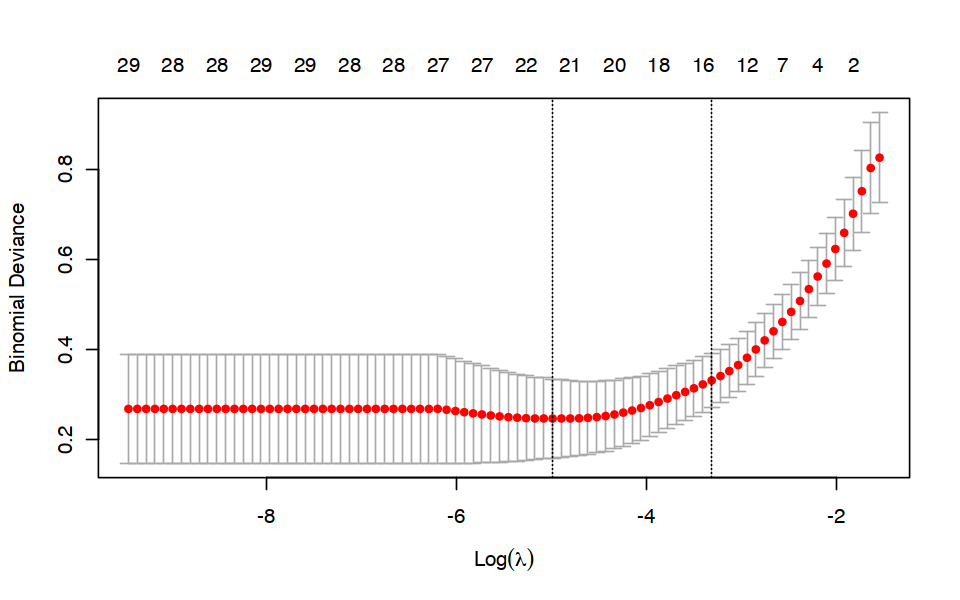

In [733]:
options(repr.plot.width = 8, repr.plot.height = 5)

plot(cv_model) 

In [734]:
nfolds = 10

val_index = createDataPartition(became_data$response_var, p = 0.5, list = FALSE)
became_val = became_data

indexes = as.data.frame(createDataPartition(became_val$response_var, p = 0.7, list = FALSE, times=nfolds))

predictors = list(
    'min_lambda' = list(),
    'se_lamdba' = list()
)
for(k in 1:nfolds){
    
    index = indexes[,k]
    became_data_train = became_val[index,]
    
    x = became_data_train[,grepl('^X',colnames(became_val))]
    y = became_data_train$response_var
    
    min_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_min, family='binomial')
    co = coef(min_model)[,1]
    lambda_min_predictors = names(co[abs(co)>0])
    
    se_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_1se, family='binomial')
    co = coef(se_model)[,1]
    lambda_se_predictors = names(co[abs(co)>0])
    
    predictors[['min_lambda']][[as.character(k)]] = lambda_min_predictors
    predictors[['se_lambda']][[as.character(k)]] = lambda_se_predictors
    
}



Setting levels: control = 0, case = 1

Setting direction: controls < cases

Using response_var as id variables



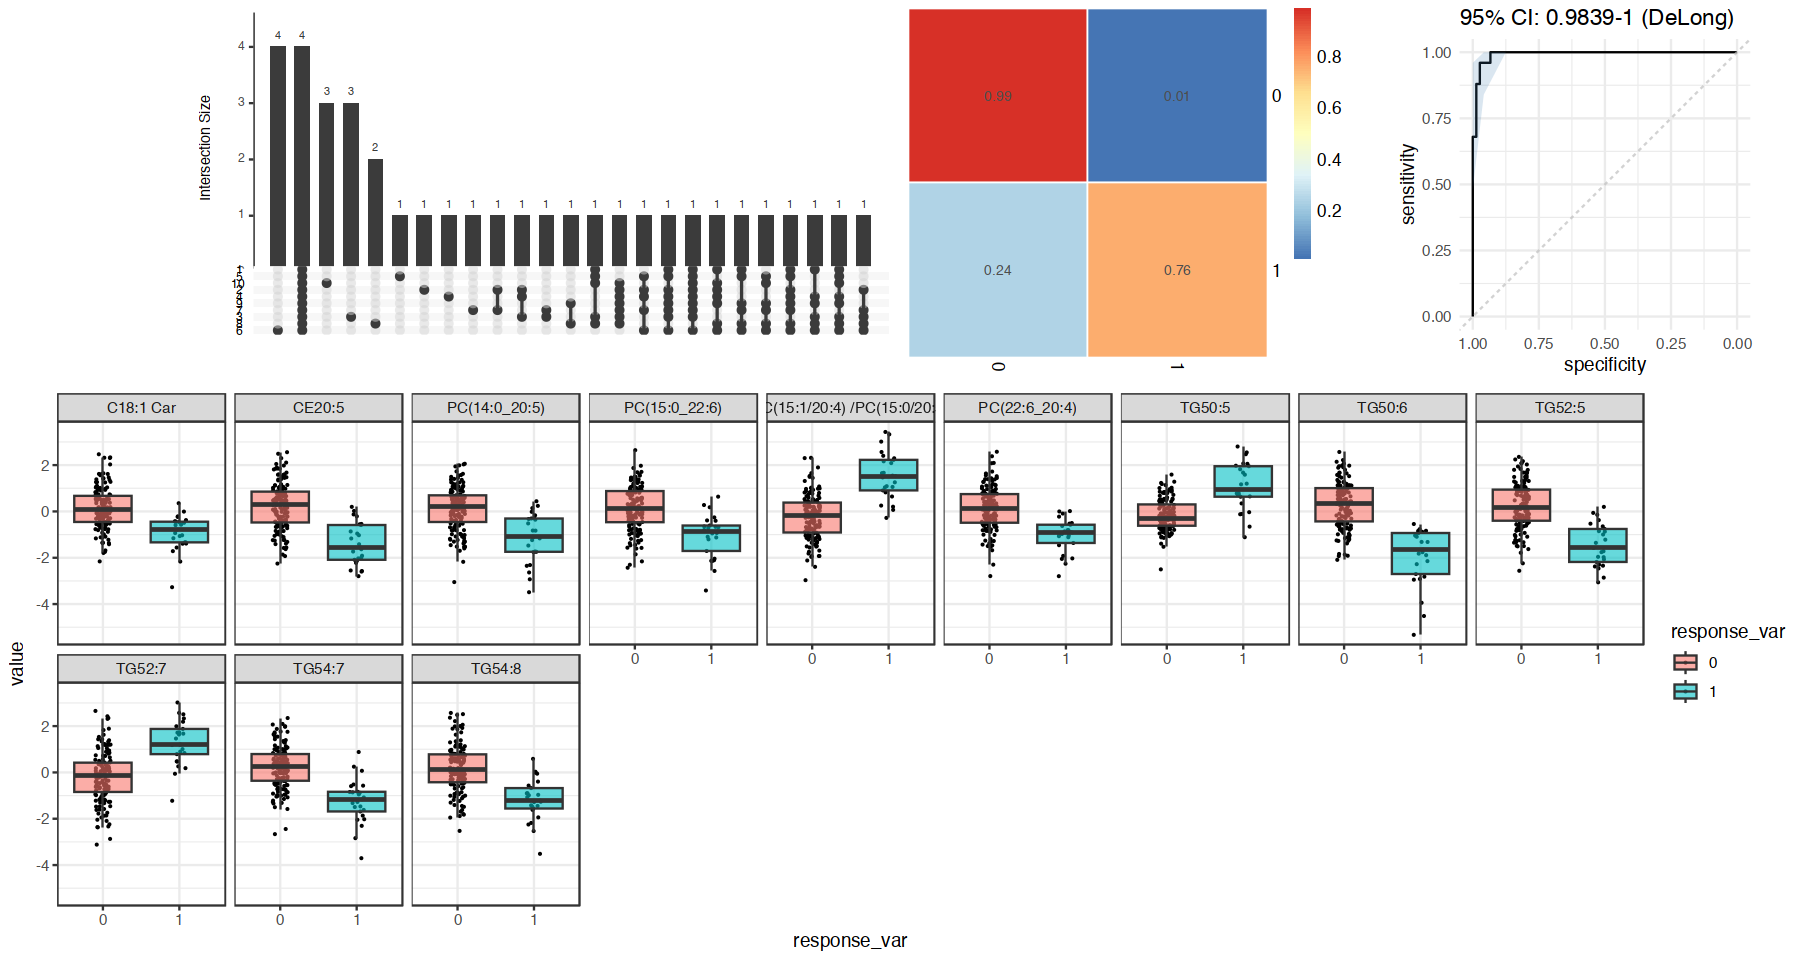

In [735]:
pup = as.ggplot(upset(fromList(predictors[['se_lambda']]),order.by='freq',nsets=nfolds))

vec = rep(0, length(unique(unlist(predictors[['se_lambda']]))))
names(vec) = unique(unlist(predictors[['se_lambda']]))
for(i in unique(unlist(predictors[['se_lambda']]))){
    for(ele in 1:length(predictors[['se_lambda']])){
      if(i %in% predictors[['se_lambda']][[ele]]){
         vec[i]=vec[i]+1   
      }
    }
}
vec = vec/length(predictors[['se_lambda']])

common_elements_se = names(vec[vec>=.6])
common_elements_se = common_elements_se[common_elements_se!='(Intercept)']

new_model = glmnet(as.matrix(x[,common_elements_se]), 
                   y, alpha = 1, lambda = lambda_1se, family='binomial')

#use fitted best model to make predictions
x_test = as.matrix(became_val[,grepl('^X',colnames(became_data))])

preds =  predict(new_model, s = lambda_1se, newx = x_test[,common_elements_se],type='response')
y_predicted <- table(became_val$response_var,round(preds))
for(i in 1:nrow(y_predicted)){y_predicted[i,] = y_predicted[i,]/sum(y_predicted[i,])}
ph = as.ggplot(pheatmap::pheatmap(y_predicted,border_col='white',display_numbers=T,treeheight_col=0,treeheight_row=0,silent=T))

obj <- roc(became_val$response_var, as.numeric(preds), ci=TRUE, plot=FALSE)
ciobj <- ci.se(obj, specificities=seq(0, 1, l=25))
dat.ci <- data.frame(x = as.numeric(rownames(ciobj)),
                     lower = ciobj[, 1],
                     upper = ciobj[, 3])

proc = ggroc(obj) + 
    theme_minimal() + 
    geom_abline(slope=1, intercept = 1, linetype = "dashed", alpha=0.7, color = "grey") + 
    coord_equal() + 
    geom_ribbon(data = dat.ci, aes(x = x, ymin = lower, ymax = upper), fill = "steelblue", alpha= 0.2) + 
    ggtitle(capture.output(obj$ci))

boxplot_df = became_data[,c('response_var',common_elements_se)]
m = reshape2::melt(boxplot_df)
m$lipid_name = lipid_meta[m$variable,'lipid_id_became']
box = ggplot(m,aes(response_var,value,fill=response_var))+
    geom_point(position=position_jitter(width=.1),size=.1)+
    geom_boxplot(alpha=.6,outlier.shape=NA)+
    facet_wrap(~lipid_name,ncol=9)+
    theme_bw()

options(repr.plot.width = 15, repr.plot.height = 8)
cowplot::plot_grid(cowplot::plot_grid(pup,ph,proc,ncol=3,rel_widths=c(4,2,2)),box,ncol=1,rel_heights=c(2,3))

In [736]:
common_elements_se

[1] "X3"   "X16"  "X58"  "X62"  "X83"  "X97"  "X110" "X124" "X132" "X144"
[11] "X61"  "X104"

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Using response_var as id variables



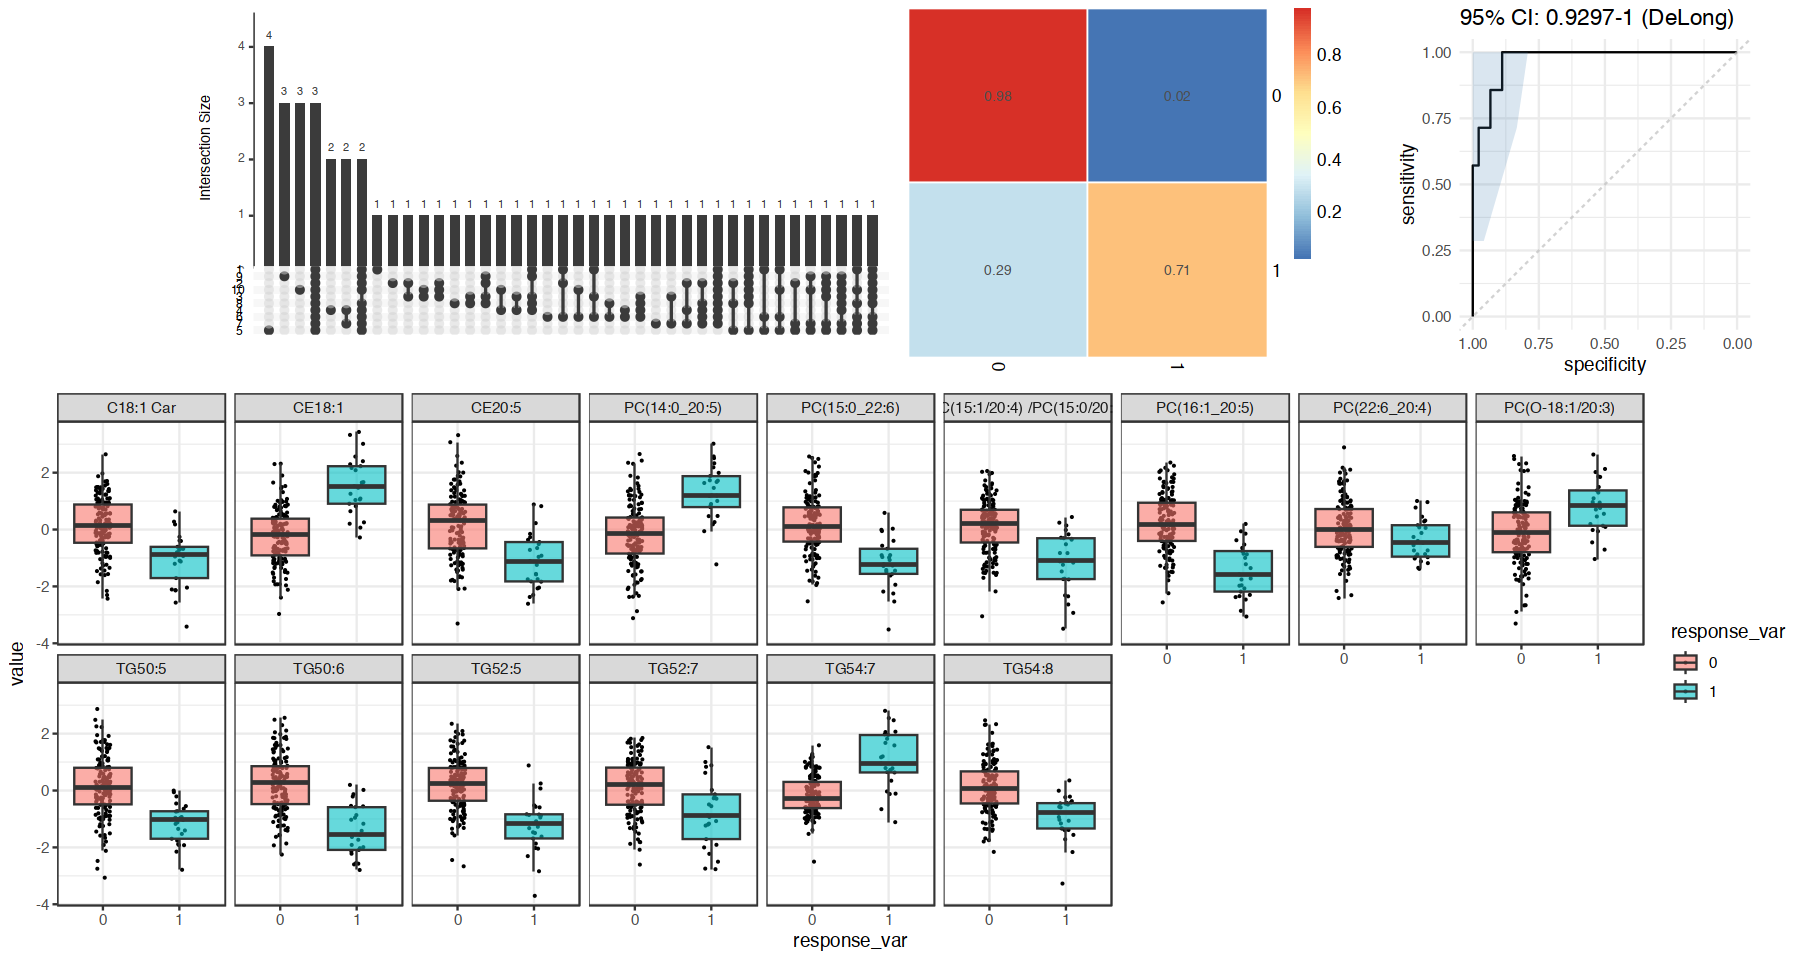

In [737]:
pup = as.ggplot(upset(fromList(predictors[['min_lambda']]),order.by='freq',nsets=nfolds))

vec = rep(0, length(unique(unlist(predictors[['min_lambda']]))))
names(vec) = unique(unlist(predictors[['min_lambda']]))
for(i in unique(unlist(predictors[['min_lambda']]))){
    for(ele in 1:length(predictors[['min_lambda']])){
      if(i %in% predictors[['min_lambda']][[ele]]){
         vec[i]=vec[i]+1   
      }
    }
}
vec = vec/length(predictors[['min_lambda']])

common_elements_min = names(vec[vec>=.6])
common_elements_min = common_elements_min[common_elements_min!='(Intercept)']

new_model = glmnet(as.matrix(x[,common_elements_min]), 
                   y, alpha = 1, lambda = lambda_min, family='binomial')

#use fitted best model to make predictions
x_test = as.matrix(became_data[-index,grepl('^X',colnames(became_data))])

preds =  predict(new_model, s = lambda_min, newx = x_test[,common_elements_min],type='response')

y_predicted <- table(became_data[-index,]$response_var,round(preds))
for(i in 1:nrow(y_predicted)){y_predicted[i,] = y_predicted[i,]/sum(y_predicted[i,])}
ph = as.ggplot(pheatmap::pheatmap(y_predicted,border_col='white',display_numbers=T,treeheight_col=0,treeheight_row=0,silent=T))

obj <- roc(became_data[-index,]$response_var, as.numeric(preds), ci=TRUE, plot=FALSE)
ciobj <- ci.se(obj, specificities=seq(0, 1, l=25))
dat.ci <- data.frame(x = as.numeric(rownames(ciobj)),
                     lower = ciobj[, 1],
                     upper = ciobj[, 3])

proc = ggroc(obj) + 
    theme_minimal() + 
    geom_abline(slope=1, intercept = 1, linetype = "dashed", alpha=0.7, color = "grey") + 
    coord_equal() + 
    geom_ribbon(data = dat.ci, aes(x = x, ymin = lower, ymax = upper), fill = "steelblue", alpha= 0.2) + 
    ggtitle(capture.output(obj$ci))

boxplot_df = became_data[,c('response_var',common_elements_min)]
m = reshape2::melt(boxplot_df)
m$lipid_name = lipid_meta[m$variable,'lipid_id_became']
box = ggplot(m,aes(response_var,value,fill=response_var))+
    geom_point(position=position_jitter(width=.1),size=.1)+
    geom_boxplot(alpha=.6,outlier.shape=NA)+
    facet_wrap(~lipid_name,ncol=9)+
    theme_bw()

options(repr.plot.width = 15, repr.plot.height = 8)
cowplot::plot_grid(cowplot::plot_grid(pup,ph,proc,ncol=3,rel_widths=c(4,2,2)),box,ncol=1,rel_heights=c(2,3))

In [738]:
common_elements_min

[1] "X16"  "X58"  "X73"  "X83"  "X84"  "X92"  "X94"  "X104" "X110" "X124"
[11] "X132" "X144" "X3"   "X61"  "X114"

In [746]:
rf_minimal = c('X64','X134','X3','X16','X119')

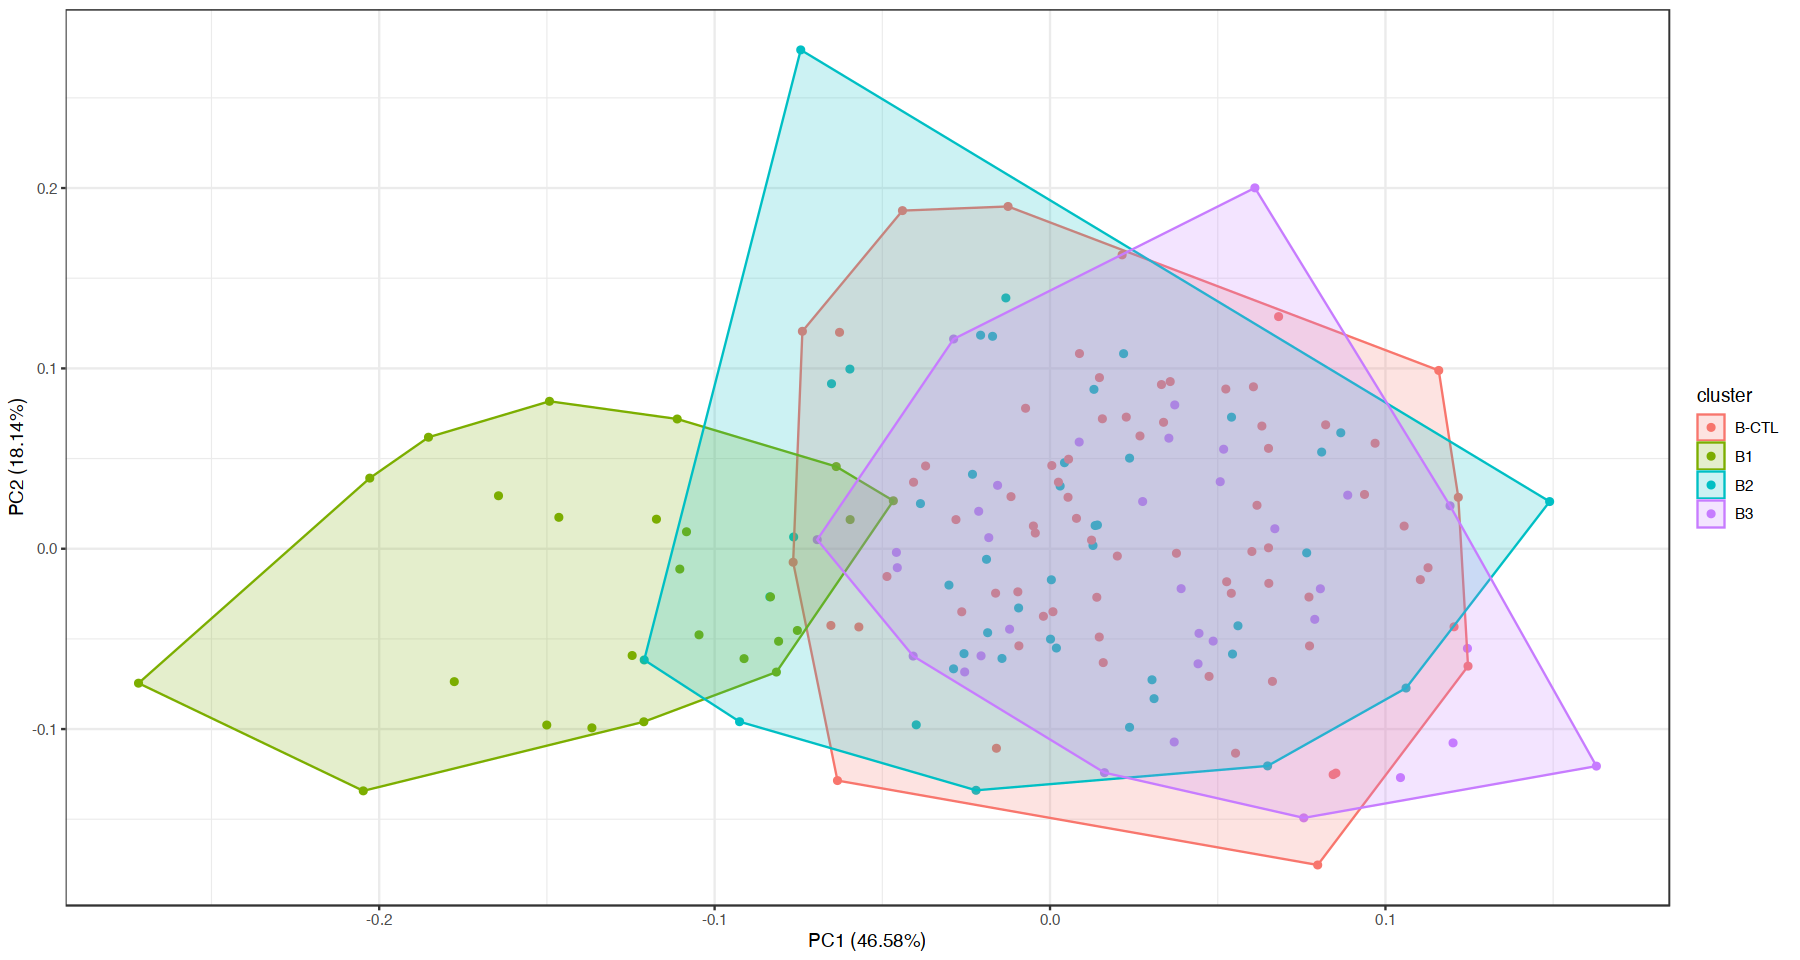

In [747]:
autoplot(prcomp(became_data[,rf_minimal]),data=became_meta,col='cluster',frame=T)+theme_bw()

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


        X1         X2         X3         X4         X5         X6         X7 
 1233.8292   875.8761  1260.1917  3326.7953   621.3455  1038.5411  1709.1056 
        X8         X9        X10        X11        X12        X13        X14 
  475.9035  1148.3924  1231.7314  3998.6467 27680.1382  1061.4980  4168.0352 
       X15        X16        X17        X18        X19        X20        X21 
16017.1682   913.6050  1848.2581  2508.8918   946.5189  2665.8488   579.9413 
       X22        X23        X24        X25        X26        X27        X28 
 1526.4263  3432.3416  5444.7288 23033.5189 17780.5724  1271.4928 16845.4081 
       X29        X30        X31        X32        X33        X34        X35 
 9642.1656  2302.9100   513.9648   776.6649  4027.3716   613.7366  3446.5176 
       X36        X37        X38        X39        X40        X41        X42 
 7595.1134  7340.9087  2017.0952  1886.6180  1390.0117   794.8435  9547.5059 
       X43        X44        X45        X46        X47        X4

In [138]:
# Check for outliers and influential observations
# Replace 'your_model' with the logistic regression model
influence_obj <- influence(glm(response_var ~ ., data = became_data, family = "binomial"))

# Display influential observations
print(influence_obj)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


$hat
     X10299      X10301      X10302      X10303      X10304      X10305 
0.992720576 0.991579436 0.999128468 0.998718974 0.998975404 0.998860057 
     X10306      X10308      X10309      X10310      X10332      X10333 
0.988710542 0.996187735 0.988205238 0.995548697 0.999608277 0.996028317 
     X10334      X10335      X10336      X10337      X10338      X10339 
0.997528910 0.996909107 0.991906145 0.998866497 0.998651867 0.999331242 
     X10340      X10342      X10343      X10363      X10364      X10365 
0.998296265 0.997587203 0.998627714 0.988851505 0.997438240 0.996953970 
     X10366      X10367      X10368      X10369      X10370      X10371 
0.985851031 0.994371733 0.964791399 0.999865433 0.999532020 0.995167603 
     X10372      X10374      X10394      X10395      X10396      X10398 
0.990058983 0.001233787 0.997377118 0.006083245 0.998661672 0.996502690 
     X10399      X10400      X10401      X10402      X10403      X10404 
0.999968787 0.987960124 0.985389632 0.98403097

In [1]:
# To implement the method described in the paper, we will perform logistic regression analysis with forward-backward
# feature selection using the Bayesian Information Criterion (BIC). In R, this can be done using the step() function 
# which automatically performs stepwise model selection. To evaluate model performance, we'll use ROC curves and compute 
# the area under the curve (AUC) along with its 95% confidence intervals using bootstrapping from the pROC package.
# 
# Let's assume we have a dataframe data where the response (response_var) is binary (reflecting two classes, e.g., disease and no disease),
# and predictor variables include identified lipids and other associated features.
# 
# Here's a simplified outline of the steps to follow:
# 
# Split the data into training and testing sets (optional and depending on the exact setup).
# Start with a null model and perform stepwise selection to identify important lipids.
# Build a second model including important lipids from the first step and allow other features to enter or leave the model.
# Assess the final model performance using ROC curves and calculate the AUC with bootstrapped confidence intervals.
# Below is a sample R script that follows this description:
# 
# # Assuming data is your dataframe and response_var is your binary response variable
# 
# This code is simply a template and will need to be adapted specifically to your data and context. For example, you'll need to 
# replace response_var with the actual name of your response variable, and lipid1, lipid2, feature1, feature2, etc., with the names
# of your specific lipids and features. The ... is a placeholder for additional variables.
# 
# Please also note that actual variable names and the logic for the upper and lower scope in the step() function depend on the data
# and analysis at hand. You should ensure that the scope for stepwise selection includes only appropriate predictors based on the 
# specific details and constraints of your data and study. Additionally, the test_data evaluation should only be done if the model 
# is not solely evaluated in the paper and a separate test set is available or constructed.

In [129]:

library(MASS)
library(pROC)
library(dplyr) # for data manipulation



In [130]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

became_data = scaled_df[rownames(subset(meta,cohort=='BECAME')),]
became_meta = meta[rownames(became_data),]

Start:  AIC=148.71
response_var ~ 1

       Df Deviance     AIC
+ X62   1   71.882  82.212
+ X64   1   82.032  92.362
+ X3    1   85.601  95.931
+ X61   1   91.346 101.675
+ X83   1   92.694 103.023
+ X78   1   97.256 107.585
+ X110  1   98.158 108.488
+ X132  1   98.535 108.864
+ X37   1   99.686 110.016
+ X71   1  100.276 110.606
+ X51   1  103.940 114.269
+ X144  1  105.335 115.664
+ X38   1  106.099 116.429
+ X67   1  106.783 117.112
+ X58   1  106.916 117.246
+ X8    1  107.589 117.918
+ X4    1  108.335 118.664
+ X97   1  109.457 119.786
+ X142  1  109.915 120.245
+ X133  1  110.017 120.346
+ X11   1  110.039 120.369
+ X1    1  110.622 120.952
+ X94   1  111.064 121.394
+ X128  1  111.160 121.490
+ X39   1  111.202 121.532
+ X69   1  111.988 122.318
+ X56   1  113.115 123.444
+ X46   1  113.172 123.501
+ X124  1  113.259 123.589
+ X104  1  113.769 124.098
+ X16   1  113.831 124.161
+ X63   1  114.072 124.402
+ X127  1  114.855 125.184
+ X143  1  115.080 125.409
+ X6    1  115.133

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


       Df Deviance    AIC
+ X134  1   13.968 39.792
+ X110  1   24.543 50.367
+ X119  1   25.705 51.529
+ X37   1   27.963 53.787
+ X125  1   27.980 53.804
+ X144  1   28.153 53.977
+ X121  1   28.243 54.067
+ X124  1   29.331 55.155
+ X143  1   29.465 55.289
+ X36   1   29.700 55.524
<none>      35.693 56.352
+ X21   1   30.590 56.414
+ X29   1   30.665 56.489
+ X24   1   30.772 56.596
+ X73   1   30.810 56.634
+ X26   1   30.974 56.798
+ X16   1   30.996 56.820
+ X2    1   31.042 56.866
+ X126  1   31.298 57.122
+ X19   1   31.506 57.330
+ X22   1   31.651 57.475
+ X117  1   31.782 57.606
+ X23   1   31.796 57.620
+ X130  1   31.948 57.772
+ X115  1   32.085 57.909
+ X33   1   32.163 57.986
+ X38   1   32.361 58.185
+ X35   1   32.386 58.210
+ X96   1   32.508 58.332
+ X133  1   32.668 58.492
+ X32   1   32.732 58.556
+ X93   1   32.833 58.657
+ X84   1   32.842 58.665
+ X20   1   32.945 58.768
+ X49   1   33.015 58.839
+ X17   1   33.159 58.983
+ X154  1   33.304 59.127
+ X27   1   

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Step:  AIC=39.79
response_var ~ X62 + X3 + X97 + X134



...


Step:  AIC=30.99
response_var ~ X62 + X3 + X97 + X134 + X82



Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”

       Df Deviance    AIC
<none>        0.00  30.99
+ X80   1     0.00  36.15
+ X61   1     0.00  36.15
+ X1    1     0.00  36.15
+ X2    1     0.00  36.15
+ X105  1     0.00  36.15
+ X29   1     0.00  36.15
+ X161  1     0.00  36.15
+ X156  1     0.00  36.15
+ X141  1     0.00  36.15
+ X24   1     0.00  36.15
+ X104  1     0.00  36.15
+ X108  1     0.00  36.15
+ X84   1     0.00  36.15
+ X26   1     0.00  36.15
+ X103  1     0.00  36.15
+ X125  1     0.00  36.15
+ X151  1     0.00  36.15
+ X60   1     0.00  36.15
+ X124  1     0.00  36.15
+ X23   1     0.00  36.15
+ X155  1     0.00  36.15
+ X142  1     0.00  36.15
+ X110  1     0.00  36.15
+ X42   1     0.00  36.15
+ X119  1     0.00  36.15
+ X93   1     0.00  36.15
+ X44   1     0.00  36.15
+ X114  1     0.00  36.15
+ X28   1     0.00  36.15
+ X115  1     0.00  36.15
+ X59   1     0.00  36.15
+ X47   1     0.00  36.15
+ X77   1     0.00  36.15
+ X148  1     0.00  36.15
+ X51   1     0.00  36.15
+ X25   1     0.00  36.15
+ X54   1   


Call:
glm(formula = response_var ~ X62 + X3 + X97 + X134 + X82, family = "binomial", 
    data = train_data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-1.384e-03  -2.000e-08  -2.000e-08  -2.000e-08   1.522e-03  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -3032.6    83094.0  -0.036    0.971
X62          -1113.9    30760.5  -0.036    0.971
X3             717.6    19590.1   0.037    0.971
X97           -994.9    27464.0  -0.036    0.971
X134         -1114.2    30371.0  -0.037    0.971
X82            130.8     3891.3   0.034    0.973

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.4354e+02  on 174  degrees of freedom
Residual deviance: 6.7191e-06  on 169  degrees of freedom
AIC: 12

Number of Fisher Scoring iterations: 25


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Warning message in ci.auc.roc(roc_obj, boot.n = 1000):
“ci.auc() of a ROC curve with AUC == 1 is always 1-1 and can be misleading.”


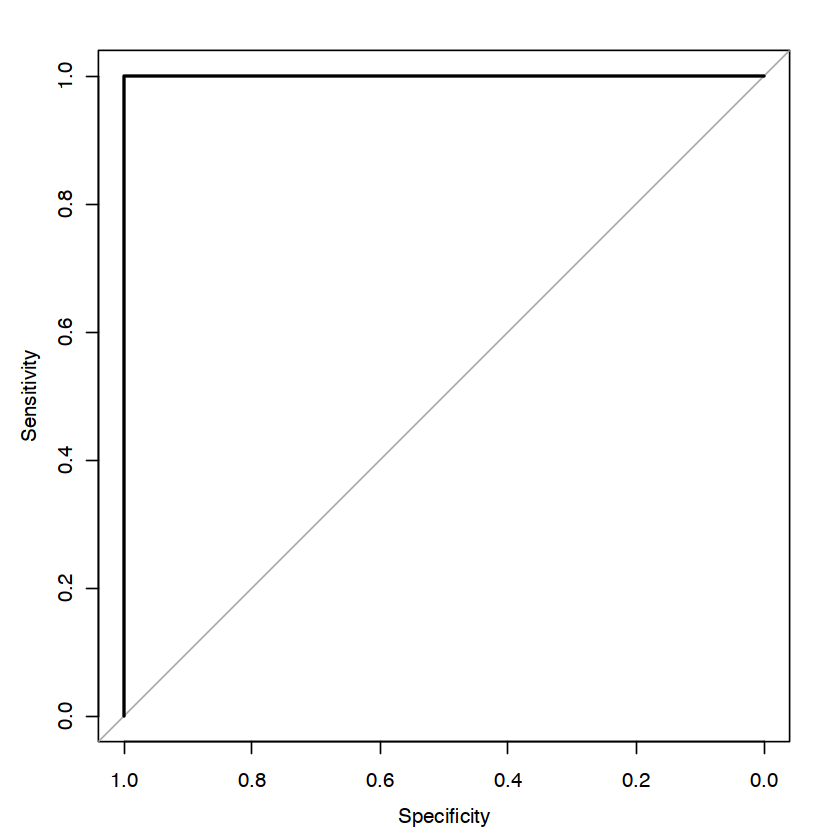

In [131]:
lipids = colnames(became_data)
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'cluster']=='B1'))

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))

# Step 1: Split the data (optional, if needed)
set.seed(123) # for reproducibility
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
train_data <- became_data
test_data <- became_data

# Step 2: Forward-backward feature selection with BIC on lipids
null_model <- glm(null_model_formula, data = train_data, family = 'binomial')
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, upper = lipids_formula), 
                     k = log(nrow(train_data))) # trace=FALSE suppresses output

# Print out the selected lipid model
summary(lipids_model)


# Step 4: Evaluation of the final model with ROC and AUC
probabilities <- predict(lipids_model, newdata = test_data, type = "response")
roc_obj <- roc(test_data$response_var, probabilities)

# ROC curve
plot(roc_obj)

# AUC with 95% bootstrap confidence intervals
auc_value <- auc(roc_obj)
ci <- ci.auc(roc_obj, boot.n = 1000) # number of bootstraps



In [123]:
table(became_data$response_var)


  0   1 
150  25 

In [125]:
# Print AUC and 95% Confidence Interval
print(paste("AUC:", auc_value))
print(paste("95% CI:", ci[1], "-", ci[3]))

[1] "AUC: 1"
[1] "95% CI: 1 - 1"


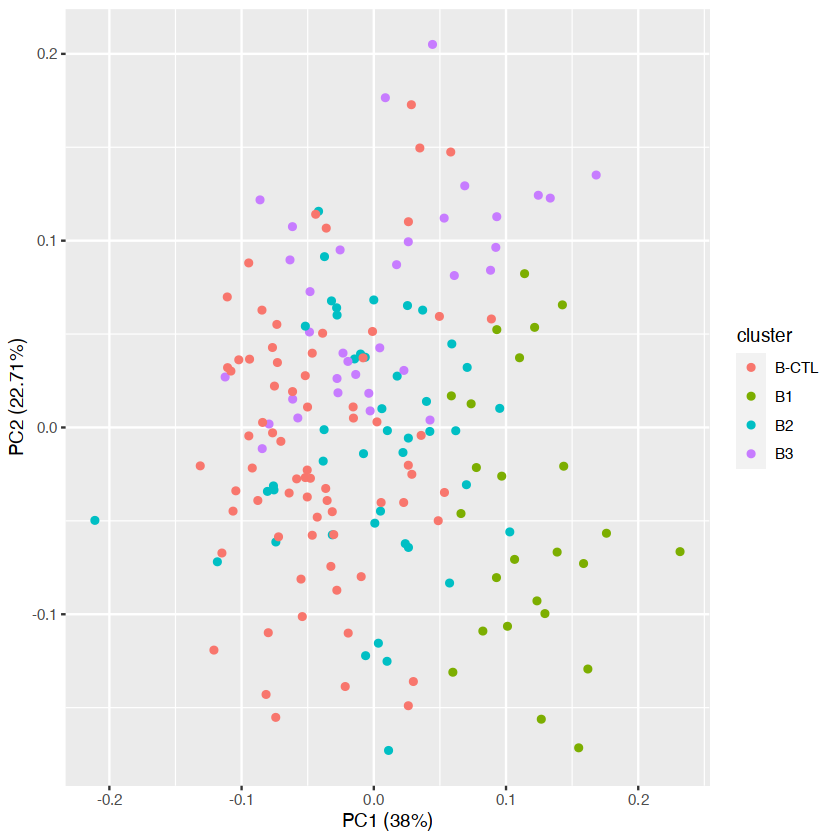

In [119]:
library(ggfortify)
lipids_selected = names(coef(lipids_model)[2:length(coef(lipids_model))])

autoplot(prcomp(became_data[,lipids_selected]),data=became_meta,col='cluster')

In [9]:
lipids_model$model


           Length Class  Mode     
lambda     100    -none- numeric  
cvm        100    -none- numeric  
cvsd       100    -none- numeric  
cvup       100    -none- numeric  
cvlo       100    -none- numeric  
nzero      100    -none- numeric  
call         6    -none- call     
name         1    -none- character
glmnet.fit  13    lognet list     
lambda.min   1    -none- numeric  
lambda.1se   1    -none- numeric  
index        2    -none- numeric  

In [15]:
library(readxl)

In [22]:
head(became_meta)

,ech..Lipidomique,pheno,cluster.Became,ID.unique,ID_JTL
,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,10297,HFpEF,1,2,2
2,10298,HFpEF,1,9,9
3,10299,HFpEF,3,31,31
4,10301,HFpEF,2,57,57
5,10302,HFpEF,2,120,120
6,10303,HFpEF,2,122,122


In [65]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
became_num = data.frame(t(became[,-c(1:7)]))
became_tmp = became_meta[,c(1:3)]
colnames(became_tmp) = c('id','group','cluster')
became_tmp$cluster = paste0('B',became_tmp$cluster)
became_tmp$cohort = 'BECAME'


In [66]:
rownames(became_meta) = paste0('X',became_meta[,1])

In [67]:
head(became_meta)

,ech..Lipidomique,pheno,cluster.Became,ID.unique,ID_JTL
,<dbl>,<chr>,<chr>,<dbl>,<dbl>
X10297,10297,HFpEF,1,2,2
X10298,10298,HFpEF,1,9,9
X10299,10299,HFpEF,3,31,31
X10301,10301,HFpEF,2,57,57
X10302,10302,HFpEF,2,120,120
X10303,10303,HFpEF,2,122,122


In [68]:
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}

In [69]:
lipids = colnames(became_num)
common = rownames(became_meta)[rownames(became_meta)%in%rownames(became_num)]
became_num = became_num[common,]
became_num$response_var = as.factor(as.numeric(became_meta[common,'pheno']=='HFpEF'))


In [70]:

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))


In [76]:
library(caret)

Loading required package: ggplot2

Loading required package: lattice



In [78]:
# Step 1: Split the data (optional, if needed)
set.seed(123) # for reproducibility
# Create an index for the train-test split
index <- createDataPartition(became_num$response_var, p = 0.7, list = FALSE)

# Create the training and testing sets
train_data <- became_num[index, ]
test_data <- became_num[-index, ]


In [79]:
# Step 2: Forward-backward feature selection with BIC on lipids

null_model <- glm(null_model_formula, data = train_data, family = binomial)
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, upper = lipids_formula), 
                     k = log(nrow(train_data)),
                     trace=FALSE) #  suppresses output

# Print out the selected lipid model
summary(lipids_model)



Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Call:
glm(formula = response_var ~ X38 + X77 + X100 + X21 + X109 + 
    X39 + X58, family = binomial, data = train_data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-8.795e-04  -2.000e-08   2.000e-08   2.000e-08   7.653e-04  

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)  1.122e+03  5.304e+04   0.021    0.983
X38          8.946e-03  4.196e-01   0.021    0.983
X77         -1.191e-04  5.430e-03  -0.022    0.983
X100        -8.785e-05  4.138e-03  -0.021    0.983
X21          1.968e-03  9.221e-02   0.021    0.983
X109        -1.934e-03  8.992e-02  -0.022    0.983
X39          4.312e-04  1.978e-02   0.022    0.983
X58         -2.928e-03  1.378e-01  -0.021    0.983

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.6798e+02  on 123  degrees of freedom
Residual deviance: 1.7072e-06  on 116  degrees of freedom
AIC: 16

Number of Fisher Scoring iterations: 25


Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] "AUC: 0.892857142857143"
[1] "95% CI: 0.810533722338617 - 0.975180563375668"


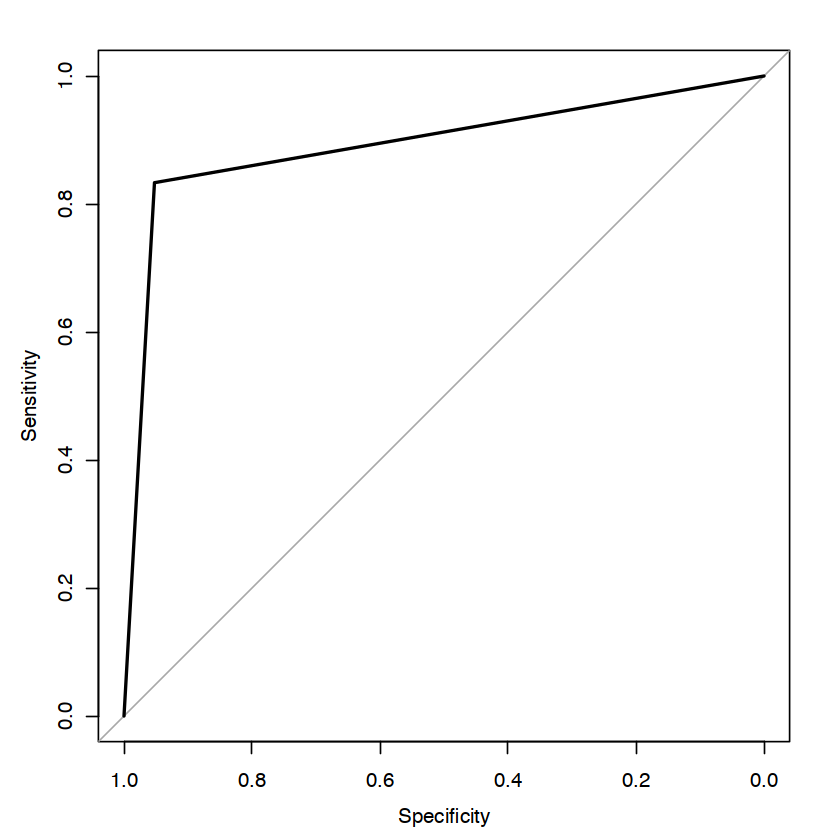

In [80]:

# Step 4: Evaluation of the final model with ROC and AUC
probabilities <- predict(lipids_model, newdata = test_data, type = "response")
roc_obj <- roc(test_data$response_var, probabilities)

# ROC curve
plot(roc_obj)

# AUC with 95% bootstrap confidence intervals
auc_value <- auc(roc_obj)
ci <- ci.auc(roc_obj, boot.n = 1000) # number of bootstraps

# Print AUC and 95% Confidence Interval
print(paste("AUC:", auc_value))
print(paste("95% CI:", ci[1], "-", ci[3]))

In [82]:
summary(lipids_model)


Call:
glm(formula = response_var ~ X38 + X77 + X100 + X21 + X109 + 
    X39 + X58, family = binomial, data = train_data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-8.795e-04  -2.000e-08   2.000e-08   2.000e-08   7.653e-04  

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)  1.122e+03  5.304e+04   0.021    0.983
X38          8.946e-03  4.196e-01   0.021    0.983
X77         -1.191e-04  5.430e-03  -0.022    0.983
X100        -8.785e-05  4.138e-03  -0.021    0.983
X21          1.968e-03  9.221e-02   0.021    0.983
X109        -1.934e-03  8.992e-02  -0.022    0.983
X39          4.312e-04  1.978e-02   0.022    0.983
X58         -2.928e-03  1.378e-01  -0.021    0.983

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.6798e+02  on 123  degrees of freedom
Residual deviance: 1.7072e-06  on 116  degrees of freedom
AIC: 16

Number of Fisher Scoring iterations: 25
